# Slopes and Intercepts in Linear Regression

A straight line can be written as

$$y = mx + c$$

- **x** is the input: the thing we already know.
- **y** is the output: the thing we want to predict.
- **m** is the **slope**: how much y changes when x goes up by 1.
- **c** is the **intercept**: the value of y when x is 0.

Linear regression is just a way of choosing good values for m and c. In this notebook we change m and c by hand
to see what each one does to the line and to the predictions, and then let scikit-learn choose them for us.

Our example throughout: predicting how many **ice creams** a shop sells from the **temperature** in °C.

Run each cell in order with Shift + Enter.

## 1. Setting up

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

COLOURS = ["#2a78d6", "#eb6834", "#1baf7a", "#6b6760"]
temps = np.linspace(10, 32, 100)   # a range of temperatures to draw lines over

This small function makes a prediction for any slope and intercept. It is the whole of the model.

In [2]:
def predict(x, m, c):
    return m * x + c

# Example: slope 8, intercept -40, on a 20 degree day
predict(20, m=8, c=-40)

120

With a slope of 8 and an intercept of -40, a 20 °C day gives 8 × 20 − 40 = **120** ice creams.

---
## 2. Changing the slope

Here we keep the intercept fixed at 0 and try four different slopes.

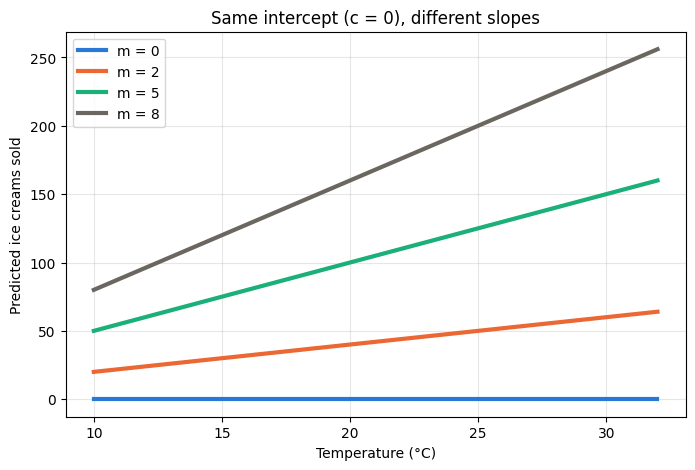

In [3]:
slopes = [0, 2, 5, 8]

plt.figure(figsize=(8, 5))
for m, colour in zip(slopes, COLOURS):
    plt.plot(temps, predict(temps, m, 0), color=colour, linewidth=3, label=f"m = {m}")
plt.xlabel("Temperature (°C)")
plt.ylabel("Predicted ice creams sold")
plt.title("Same intercept (c = 0), different slopes")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

The bigger the slope, the **steeper** the line. To see what that means for the predictions, we compare a
cool day (15 °C) with a warm day (25 °C) for each slope:

In [4]:
rows = []
for m in slopes:
    cool = predict(15, m, 0)
    warm = predict(25, m, 0)
    rows.append({"slope m": m, "15 °C": cool, "25 °C": warm, "difference": warm - cool})

pd.DataFrame(rows)

,slope m,15 °C,25 °C,difference
0,0,0,0,0
1,2,30,50,20
2,5,75,125,50
3,8,120,200,80


### What the slope tells us

- With **m = 0** the line is flat. Every day gets the same prediction, so the model is saying that temperature
  makes **no difference** to sales.
- With **m = 2**, each extra degree adds 2 ice creams. A day that is 10 degrees warmer sells 20 more.
- With **m = 8**, each extra degree adds 8 ice creams, so the same 10 degrees makes a difference of 80.

In general, if x goes up by some amount, the prediction goes up by **m times that amount**. The slope is the
part of the model that describes the **relationship** between the input and the output.

### Negative slopes

A slope can also be negative. Think about a café selling hot chocolate: the warmer it gets, the **fewer** it sells.

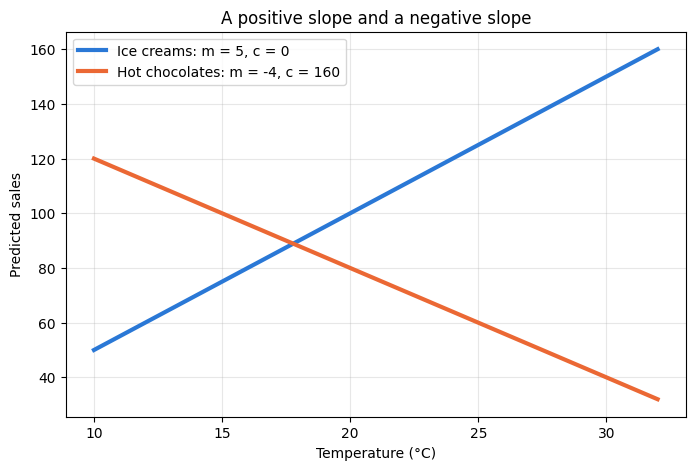

In [5]:
plt.figure(figsize=(8, 5))
plt.plot(temps, predict(temps, 5, 0), color=COLOURS[0], linewidth=3, label="Ice creams: m = 5, c = 0")
plt.plot(temps, predict(temps, -4, 160), color=COLOURS[1], linewidth=3, label="Hot chocolates: m = -4, c = 160")
plt.xlabel("Temperature (°C)")
plt.ylabel("Predicted sales")
plt.title("A positive slope and a negative slope")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

- A **positive** slope means that as x goes up, y goes **up**.
- A **negative** slope means that as x goes up, y goes **down**. Here, each extra degree means 4 fewer hot chocolates.
- The **size** of the slope (ignoring the sign) says how strong the effect is.

---
## 3. Changing the intercept

Now we do the opposite: keep the slope fixed at 5 and try three different intercepts.

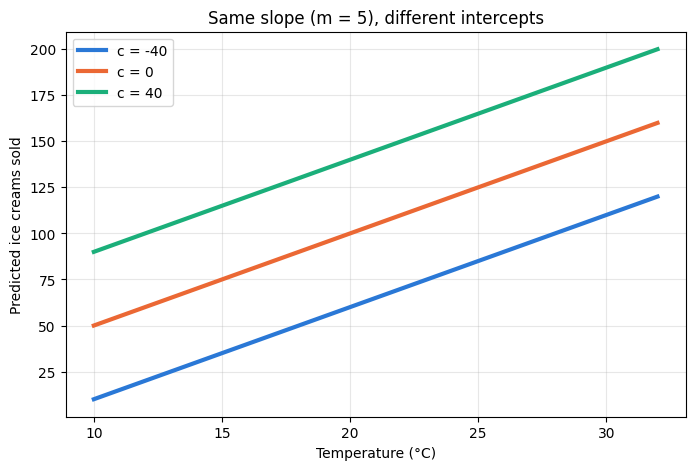

In [6]:
intercepts = [-40, 0, 40]

plt.figure(figsize=(8, 5))
for c, colour in zip(intercepts, COLOURS):
    plt.plot(temps, predict(temps, 5, c), color=colour, linewidth=3, label=f"c = {c}")
plt.xlabel("Temperature (°C)")
plt.ylabel("Predicted ice creams sold")
plt.title("Same slope (m = 5), different intercepts")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [7]:
rows = []
for c in intercepts:
    rows.append({"intercept c": c, "15 °C": predict(15, 5, c), "25 °C": predict(25, 5, c),
                 "difference": predict(25, 5, c) - predict(15, 5, c)})

pd.DataFrame(rows)

,intercept c,15 °C,25 °C,difference
0,-40,35,85,50
1,0,75,125,50
2,40,115,165,50


### What the intercept tells us

- The three lines are **parallel**. Changing the intercept slides the whole line **up or down** without
  changing how steep it is.
- Every prediction moves by the **same amount**. Going from c = 0 to c = 40 adds 40 ice creams to every day,
  whether it is cold or hot.
- The difference between a 15 °C day and a 25 °C day is **50 in every row**, because that difference depends only
  on the slope (5 × 10 = 50).

The intercept is the value of y when x is 0, which is where the line crosses the y axis. It sets the
**starting level** of the predictions.

---
## 4. Trying lines on real data

So far we have drawn lines with no data. Now we use 24 days of sales from an ice cream shop. These numbers are
made up for teaching, but they behave like real sales: warmer days usually sell more.

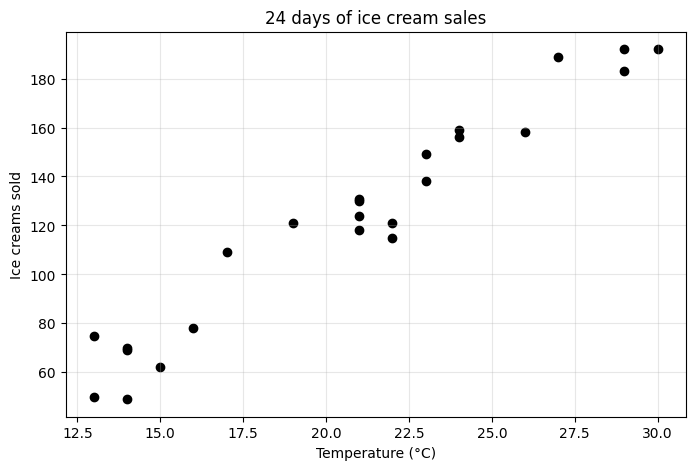

In [8]:
data = pd.DataFrame({
    "temperature": [14, 21, 23, 13, 15, 29, 13, 14, 29, 23, 19, 21, 24, 17, 14, 26, 24, 21, 27, 22, 30, 16, 22, 21],
    "ice_creams":  [49, 118, 138, 50, 62, 192, 75, 69, 183, 149, 121, 124, 159, 109, 70, 158, 156, 131, 189, 121, 192, 78, 115, 130],
})

plt.figure(figsize=(8, 5))
plt.scatter(data["temperature"], data["ice_creams"], color="black")
plt.xlabel("Temperature (°C)")
plt.ylabel("Ice creams sold")
plt.title("24 days of ice cream sales")
plt.grid(alpha=0.3)
plt.show()

Here are four guesses at a line. For each one we work out the **mean absolute error (MAE)**: the average
number of ice creams the line is out by. A smaller MAE means a better line.

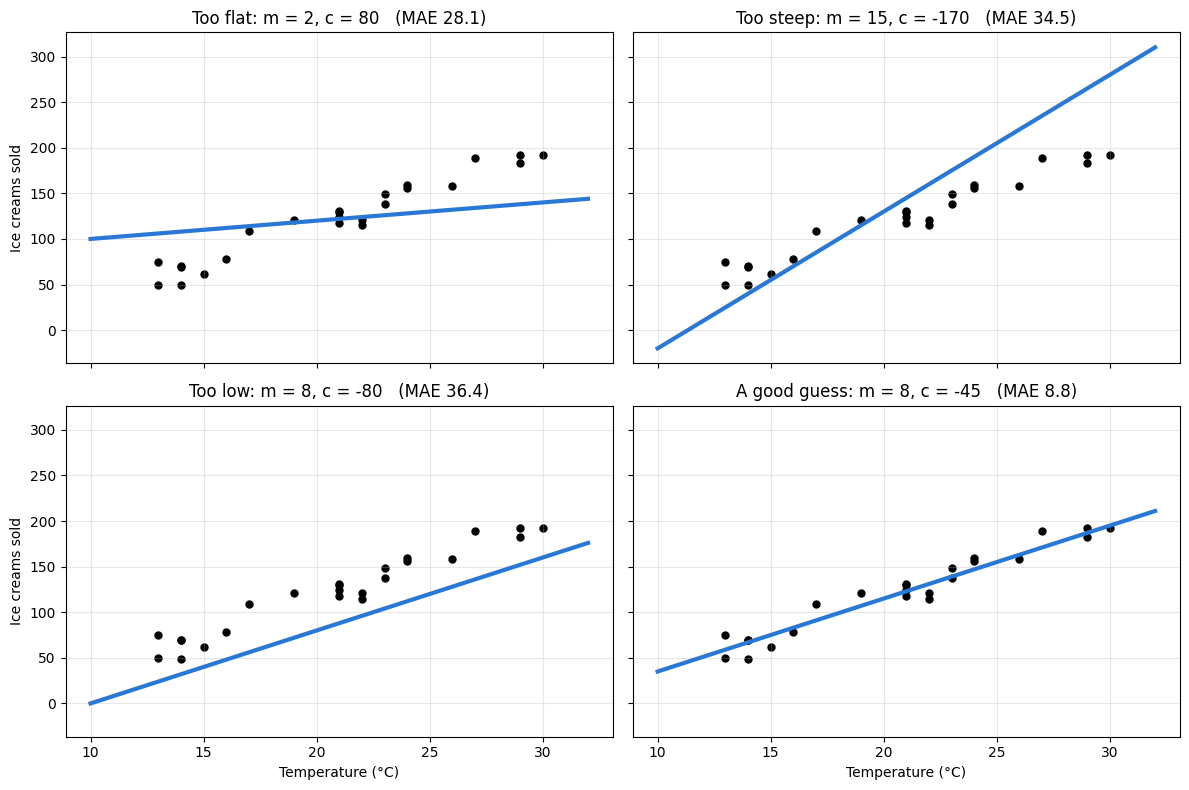

,guess,slope m,intercept c,MAE
0,Too flat,2,80,28.1
1,Too steep,15,-170,34.5
2,Too low,8,-80,36.4
3,A good guess,8,-45,8.8


In [9]:
guesses = [
    ("Too flat",      2,   80),
    ("Too steep",    15, -170),
    ("Too low",       8,  -80),
    ("A good guess",  8,  -45),
]

x = data["temperature"]
y = data["ice_creams"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
rows = []
for ax, (name, m, c) in zip(axes.flat, guesses):
    predictions = predict(x, m, c)
    mae = np.mean(np.abs(y - predictions))
    rows.append({"guess": name, "slope m": m, "intercept c": c, "MAE": round(mae, 1)})

    ax.scatter(x, y, color="black", s=25)
    ax.plot(temps, predict(temps, m, c), color=COLOURS[0], linewidth=3)
    ax.set_title(f"{name}: m = {m}, c = {c}   (MAE {mae:.1f})")
    ax.grid(alpha=0.3)

for ax in axes[1]:
    ax.set_xlabel("Temperature (°C)")
for ax in axes[:, 0]:
    ax.set_ylabel("Ice creams sold")
plt.tight_layout()
plt.show()

pd.DataFrame(rows)

### What went wrong with each guess

- **Too flat:** the slope is much too small. The line is roughly right in the middle, but it predicts too many
  on cold days and too few on hot days, because it underestimates how much temperature matters.
- **Too steep:** the slope is too big, so the mistake is the other way round: too few on cold days and far too
  many on hot days.
- **Too low:** the slope is about right, so the line has the right **shape**, but the intercept is too small
  and the whole line sits underneath the points. Every prediction is too low by a similar amount.
- **A good guess:** a sensible slope and intercept together. The line goes through the middle of the points.

A wrong **slope** gives errors that get worse towards the ends of the data. A wrong **intercept** gives errors
of a similar size everywhere.

---
## 5. Letting the computer choose

Guessing is slow. `LinearRegression` finds the slope and intercept that make the line as close to the points as
possible. (Strictly, it makes the total of the **squared** errors as small as it can.)

In [10]:
model = LinearRegression()
model.fit(data[["temperature"]], data["ice_creams"])

m_best = model.coef_[0]
c_best = model.intercept_
mae_best = np.mean(np.abs(y - predict(x, m_best, c_best)))

print(f"Slope m:     {m_best:.2f}")
print(f"Intercept c: {c_best:.2f}")
print(f"MAE:         {mae_best:.1f}")

Slope m:     8.25
Intercept c: -48.85
MAE:         8.8


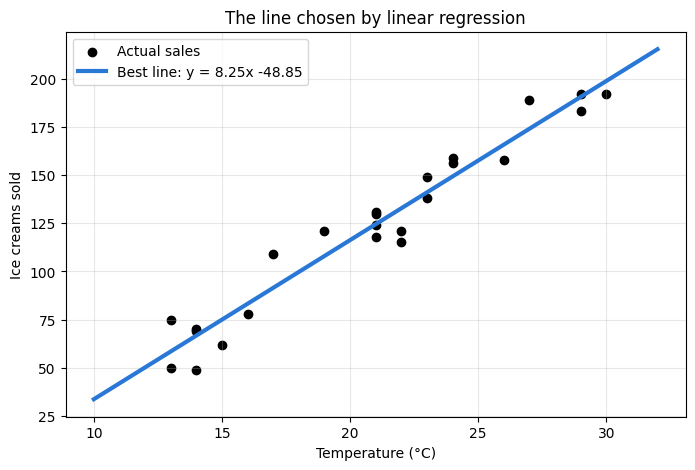

In [11]:
plt.figure(figsize=(8, 5))
plt.scatter(x, y, color="black", label="Actual sales")
plt.plot(temps, predict(temps, m_best, c_best), color=COLOURS[0], linewidth=3,
         label=f"Best line: y = {m_best:.2f}x {c_best:+.2f}")
plt.xlabel("Temperature (°C)")
plt.ylabel("Ice creams sold")
plt.title("The line chosen by linear regression")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Reading the fitted line

- The fitted slope and intercept are close to our "good guess", and the MAE is about the same. A careful guess
  can get close, but the computer gets there straight away, and can do it with many inputs at once.
- The **slope** says that each extra degree adds about 8 ice creams. That is the useful, real-world finding:
  a 10 degree warmer day means roughly 80 more sales.
- The **intercept** says that at 0 °C the shop would sell about −49 ice creams. That is impossible. It happens
  because the shop's data only covers days from 13 °C to 30 °C, and the line is being stretched well beyond the
  data it learned from. Using a model outside the range of its data is called **extrapolation**, and it is
  often unreliable.

So the intercept is needed to put the line in the right place, but it does not always have a sensible meaning
on its own. The slope is usually the more interesting number.

---
## 6. Summary

| | Slope (m) | Intercept (c) |
|---|---|---|
| What it is | How much y changes when x goes up by 1 | The value of y when x is 0 |
| Changing it makes the line | Steeper, flatter, or slope the other way | Move up or down, staying parallel |
| Effect on predictions | Bigger changes for bigger x, so the ends move most | Every prediction moves by the same amount |
| If it is wrong | Errors grow towards the ends of the data | All predictions too high or all too low |
| In scikit-learn | `model.coef_` | `model.intercept_` |

## 7. Things to try

1. Use `predict` to work out how many ice creams the fitted model predicts for a 35 °C day. Is that a sensible
   prediction? Why might it be less reliable than one for 20 °C?
2. In Section 4, add your own guess to the `guesses` list. Can you find a slope and intercept with a smaller MAE
   than "A good guess"? Can you beat the MAE that `LinearRegression` found?
3. In Section 2, add a slope of -3 to the list. What does the line look like, and what kind of product might
   behave like that?
4. Change one of the days in the data to a very unusual value, for example 300 ice creams on a 15 °C day, and
   fit the model again. What happens to the slope and the intercept?